In [9]:
import numpy as np
import h5py
import os
from simulation import run_simulation, run_tdi
from qtransform import generate_qscan
import time
from matplotlib import pyplot as plt

In [11]:
def append_sample(h5, QT, m1, m2):
    n = h5["QT"].shape[0]  # current length

    # resize all datasets by +1
    h5["QT"].resize((n + 1, QT.shape[0], QT.shape[1]))
    h5["m1"].resize((n + 1,))
    h5["m2"].resize((n + 1,))

    # store
    h5["QT"][n] = QT.astype("float32")
    h5["m1"][n] = m1
    h5["m2"][n] = m2

In [8]:
orbits_path = '../dist/orbits.h5'
simulation_path = '../dist/default_simulation_output.h5'
tdi_path = '../dist/default_tdi_output.h5'
gw_path = '../dist/default_gw_output.h5'
glitch_path = '../dist/default_glitch_output.h5'
dataset_path = "../dist/dataset.h5"

pipe = {'t0':10368000, 'dt':0.25, 'size':72000, 'gw_beta':0, 'gw_lambda':np.pi/7}

glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
             'level':0, 't_rise':1, 't_fall':1, 'inj_point':'readout_tmi_carrier_12'}]

In [12]:
H, W = 512, 512
if not os.path.exists(dataset_path):
    h5file = h5py.File(dataset_path, "a")

    if "QT" not in h5file:
        h5file.create_dataset(
            "QT", 
            shape=(0, H, W),
            maxshape=(None, H, W),  # unlimited along axis 0
            dtype="float32",
            chunks=(1, H, W),       # good practice
            compression="gzip"
        )

        h5file.create_dataset(
            "m1",   shape=(0,), maxshape=(None,), dtype="float32"
        )
        h5file.create_dataset(
            "m2",   shape=(0,), maxshape=(None,), dtype="float32"
        )


In [13]:
mass_arr = [1e5]
q_arr = [1, 10]

start = time.time()
for m in mass_arr:
    for q in q_arr:

        gws = [{'type':'BinaryInspiralGW', 'm1':m, 'm2':m*q, 'd':1e4, 
        'e':0.0, 't_inj':2.5*3600, 'domain':'freq'}]

        run_simulation(gws, glitches, pipe,
                    gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False,)
        tdi_dict = run_tdi(simulation_path, pipe)

        event = gws[0]
        t_arr, f_arr, QT = generate_qscan(tdi_dict, Q=15, channel='X', pipe=pipe, event=event, resolution=512, 
                        frange=(1e-3, 1e-1), trange=(-1, 1))
        append_sample(h5file, QT, event['m1'], event['m2'])
end = time.time()
print(f"Total time taken: {end - start} seconds")

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


Total time taken: 15.711409091949463 seconds


In [16]:
with h5py.File(dataset_path, "r") as h5:
    QT_array = h5["QT"][:]       # shape (N, 512, 512)
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]

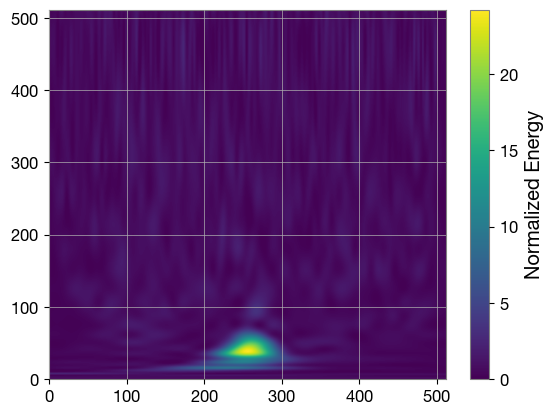

In [21]:
plt.imshow(QT_array[1], origin='lower', aspect='auto')
plt.colorbar(label='Normalized Energy')
#plt.yscale('log')